# Plot Types

SpectroChemPy provides several plotting methods. `ds.plot()` chooses
automatically, but explicit methods give you control.

`ds.plot()` uses the default geometry for the dataset dimensionality. Use the
explicit helpers below when you want the intended rendering to be obvious from
the code itself.

## Line Plot

For spectra and time-series:

In [1]:
import os
from pathlib import Path

import spectrochempy as scp

TEST_FILE = Path(os.environ.get("TEST_FILE", "irdata/nh4y-activation.spg"))

ds = scp.read(TEST_FILE)
ds = ds[:, 4000.0:650.0]  # We keep only the region that we want to display
ds.y -= ds.y[0]  # Set y coordinates as relative time  for better visualization
ds.y.ito("hour")
ds.y.title = "Time on stream"  # Update y-axis title accordingly
ds[:, 1290.0:920.0] = scp.MASKED  # We also mask a region that we do not want to display
ds1 = ds[0]  # Single spectrum

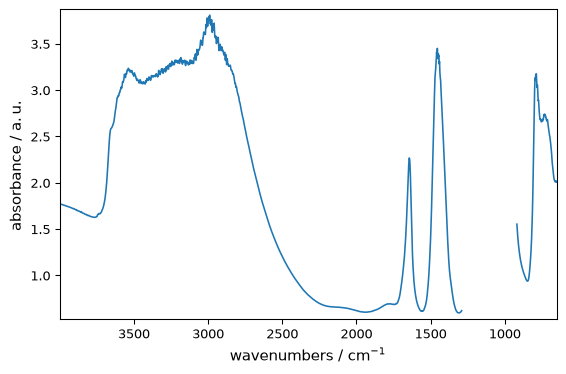

In [2]:
_ = ds1.plot()

The explicit 1D helpers are:

- `plot_pen()` for line plots,
- `plot_scatter()` for marker-based plots,
- `plot_bar()` for bar charts.

`scatter=True` is still accepted for compatibility, but `plot_scatter()` or
`method="scatter"` is clearer in new code.


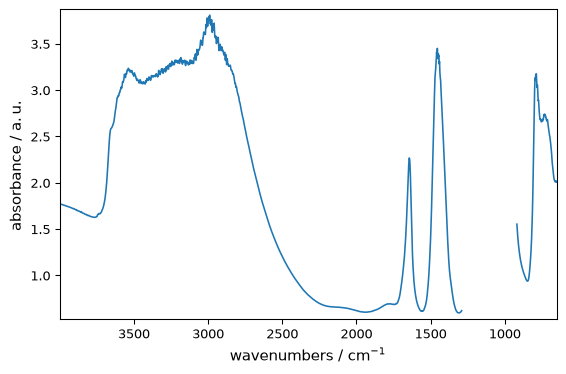

In [3]:
_ = ds1.plot_pen()

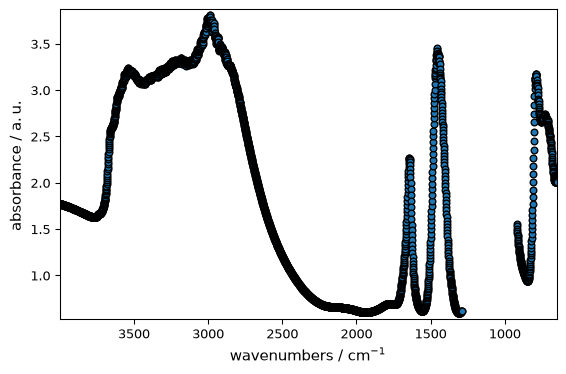

In [4]:
_ = ds1.plot_scatter(ms=5)

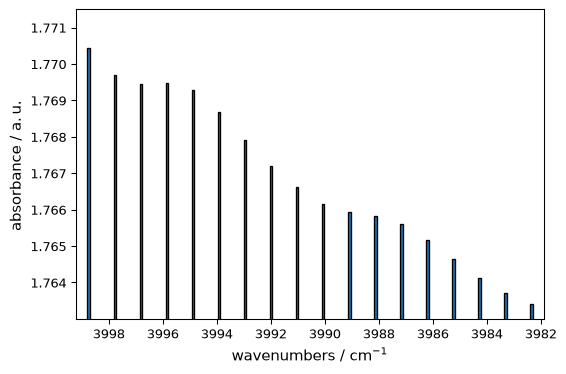

In [5]:
_ = ds1[:20].plot_bar()

Or using `plot_lines()` explicitly (canonical form):

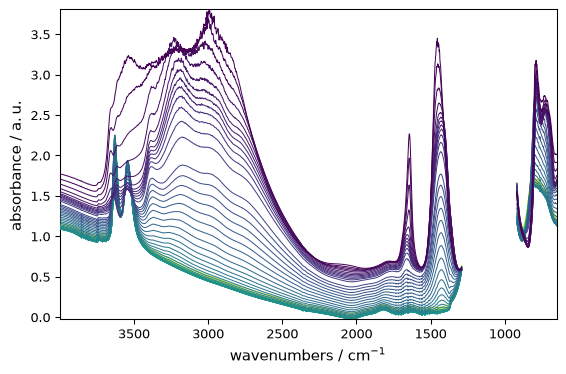

In [6]:
_ = ds.plot_lines()

## Image Plot

For 2D data where both axes are numerical:

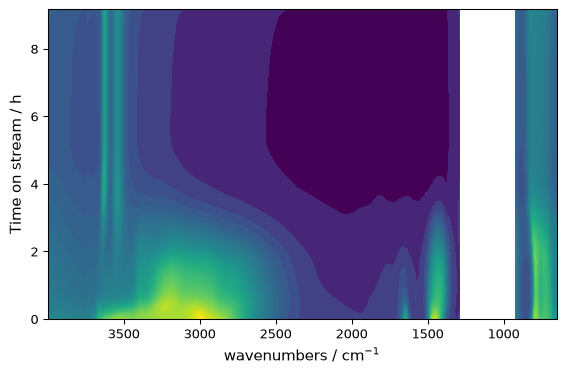

In [7]:
_ = ds.plot_image()

Request a colorbar when you want the intensity scale to be explicit:

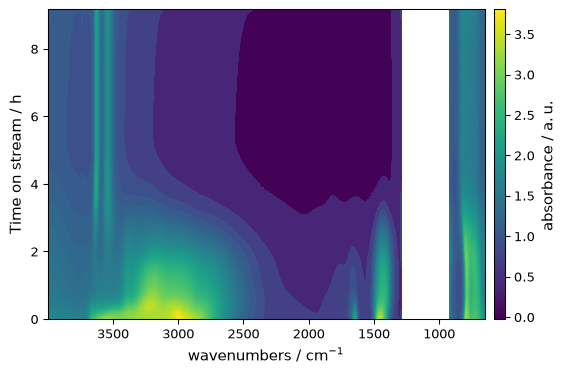

In [8]:
_ = ds.plot_image(colorbar=True)

Hide the colorbar if needed:

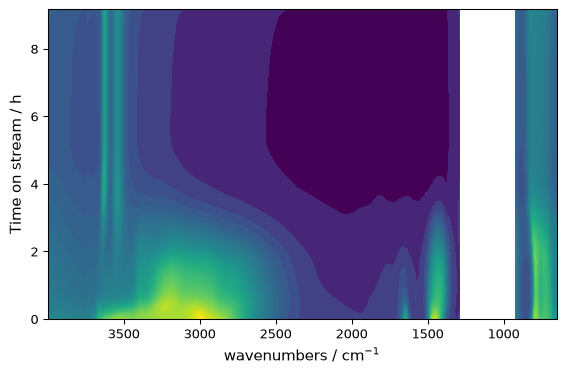

In [9]:
_ = ds.plot_image(colorbar=False)

## Contour Plot

For continuous data with smooth transitions:

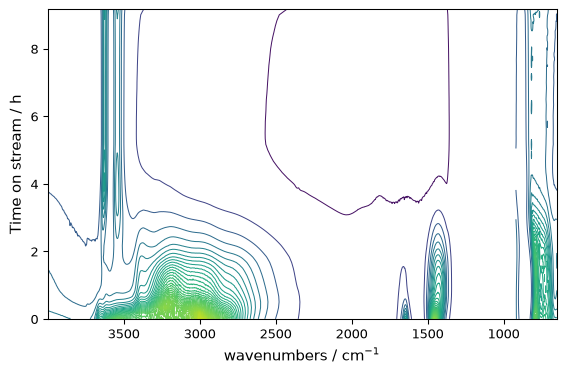

In [10]:
_ = ds.plot_contour()

Contour plots also support colorbars:

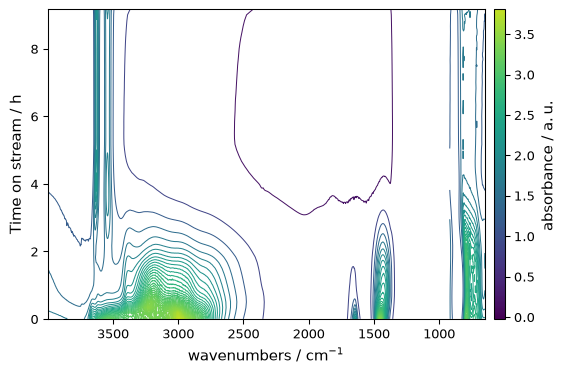

In [11]:
_ = ds.plot_contour(colorbar=True)

## Filled Contour / Image-like Plot

For image-like filled rendering, use `plot_contourf()` or `plot_image()`:

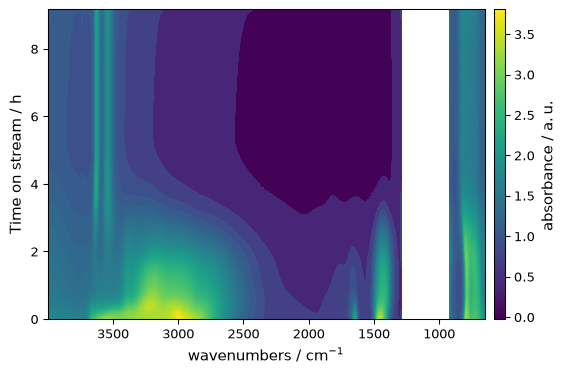

In [12]:
_ = ds.plot_contourf(colorbar=True)

## Decision Guide

| Method | Use When |
|--------|----------|
| `plot()` / `plot_lines()` | Showing spectra, time series, or stacked traces |
| `plot_pen()` / `plot_scatter()` / `plot_bar()` | Explicit 1D line, marker, or bar rendering |
| `plot_image()` | 2D field with spatial x/y axes |
| `plot_contour()` | Smooth visualization of continuous 2D data |
| `plot_contourf()` | Filled, image-like contour rendering |
| `plot_surface()` | 3D perspective view of 2D data |
| `plot_waterfall()` | 3D-style waterfall representation |

## Surface Plot

For a 3D perspective view of 2D data:

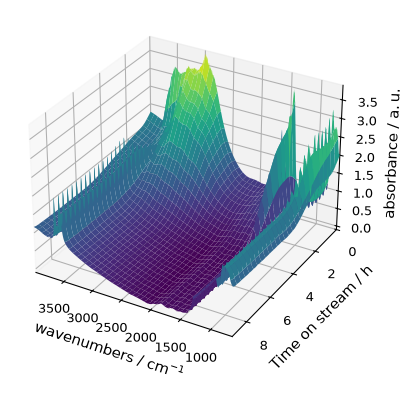

In [13]:
_ = ds.plot_surface(y_reverse=True, linewidth=0)

## Waterfall Plot

For a waterfall-style representation:

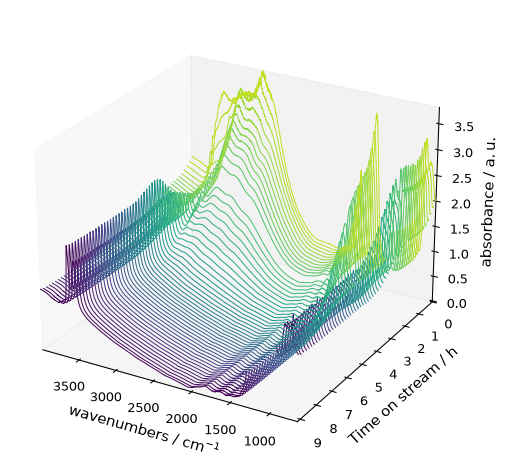

In [14]:
_ = ds.plot_waterfall(y_reverse=True, figsize=(6, 5))

## Overlay Several Datasets on One Axes

`plot_multiple()` overlays several 1D datasets on the same Matplotlib axes.
Use it when you want one shared set of axes and one combined legend.

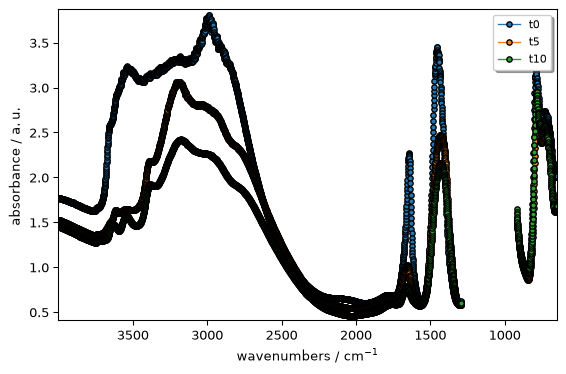

In [15]:
datasets = [ds[0], ds[5], ds[10]]
_ = scp.plot_multiple(
    datasets,
    method="scatter",
    labels=["t0", "t5", "t10"],
    legend="best",
    ms=4,
)

## Arrange Several Datasets on a Grid

`multiplot()` creates a grid of axes. Use it when each dataset should keep its
own panel rather than being overlaid.

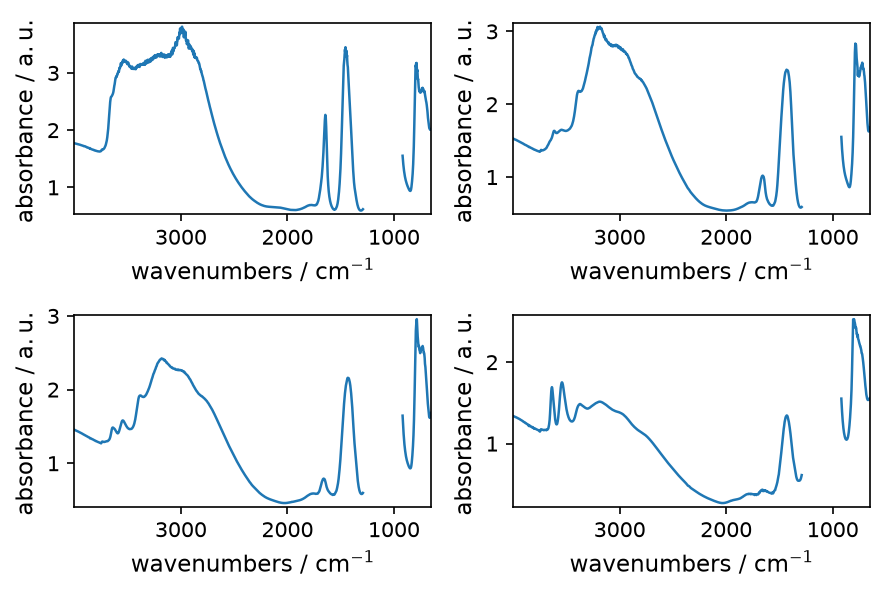

In [16]:
_ = scp.multiplot([ds[0], ds[5], ds[10], ds[15]], nrows=2, ncols=2, method="pen")

## Combining with Options

All plot methods accept the same customization options:

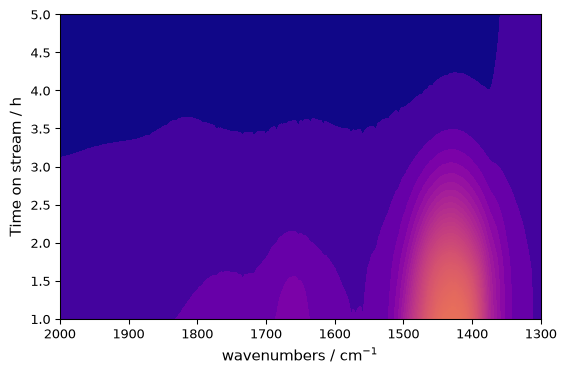

In [17]:
_ = ds.plot_image(
    cmap="plasma",
    xlim=(2000, 1300),
    ylim=(1, 5),
)

The appropriate method is chosen automatically when you call `ds.plot()`,
but explicit methods make your intent clear and provide specific functionality.

## Deprecated Method Names

The following legacy names still work, but the canonical names are preferred
for new code:

| Legacy name | Preferred name |
|-------------|----------------|
| `plot_stack()` or `method="stack"` | `plot_lines()` or `method="lines"` |
| `plot_map()` or `method="map"` | `plot_contour()` or `method="contour"` |
| `plot_image()` or `method="image"` | `plot_contourf()` when you want the canonical geometry name |

`plot_image()` remains a supported explicit helper for image-style plotting, so
choose between `plot_image()` and `plot_contourf()` based on which name makes
your intent clearer.